# Problem Setting

## Background

The 2D XY model exhibits a topological phase transition known as the Kosterlitz–Thouless (KT) transition.  
Unlike conventional second-order phase transitions, the KT transition does not involve spontaneous symmetry breaking or a simple two-phase structure.

Instead, the system exhibits:

- A low-temperature quasi-ordered phase  
- A high-temperature disordered phase  
- A nontrivial intermediate regime associated with vortex unbinding  

This makes phase identification nontrivial using standard binary classification approaches.

---

## Motivation

In many studies, machine learning models are trained to classify phases into two categories (ordered vs disordered).  
However, such approaches may:

- Implicitly enforce a two-phase interpretation  
- Fail to capture intermediate structures  
- Produce latent representations that collapse transitional regimes  

Our goal is different.

Rather than performing phase classification, we aim to:

> Learn latent representations that faithfully reflect the intrinsic structure of the system across temperature.

---

## Research Question

Can representation learning uncover:

1. Distinct low- and high-temperature structures?
2. A continuous intermediate regime?
3. Latent dimensions that correlate with physically meaningful observables?

---

## Approach

We compare four representation learning methods:

- Autoencoder (AE)
- Variational Autoencoder (VAE)
- Contrastive learning
- Helicity-Contrastive learning (proposed)

All models are trained in an unsupervised manner.

We then examine:

- UMAP embeddings of latent space
- Cluster structure as a function of temperature
- Correlation between latent variables and physical observables

The key question is whether incorporating helicity information improves structural fidelity of the learned representation.


In [8]:
# --- Load & Sanity Check ---

from pathlib import Path
import numpy as np

DATA_DIR = Path("results/notebook_data")

files = {
    "AE": DATA_DIR / "ae_latent.npz",
    "VAE": DATA_DIR / "vae_latent.npz",
    "Contrastive": DATA_DIR / "contrastive_latent_small.npz",
    "Helicity-Contrastive": DATA_DIR / "helicity_contrastive_latent_small.npz",
}

for name, fp in files.items():
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

    d = np.load(fp)

    print(f"{name:18s} | "
          f"z {d['z'].shape} {d['z'].dtype} | "
          f"T {d['T'].shape} {d['T'].dtype}")


AE                 | z (22000, 8) float32 | T (22000,) float32
VAE                | z (22000, 8) float32 | T (22000,) float32
Contrastive        | z (3000, 2048) float32 | T (3000,) float32
Helicity-Contrastive | z (3000, 2048) float32 | T (3000,) float32


In [9]:
!pip install umap-learn

[OK] AE (baseline)                | z=(3000, 8) dtype=float32 | T=(3000,) dtype=float32
[OK] VAE (baseline)               | z=(3000, 8) dtype=float32 | T=(3000,) dtype=float32
[OK] Contrastive (baseline)       | z=(3000, 2048) dtype=float32 | T=(3000,) dtype=float32
[OK] Helicity-Contrastive (proposed) | z=(3000, 2048) dtype=float32 | T=(3000,) dtype=float32
[INFO] UMAP fitting: AE (baseline)


c:\Users\shona\anaconda3\envs\xy\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] UMAP fitting: VAE (baseline)


c:\Users\shona\anaconda3\envs\xy\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] UMAP fitting: Contrastive (baseline)


c:\Users\shona\anaconda3\envs\xy\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] UMAP fitting: Helicity-Contrastive (proposed)


c:\Users\shona\anaconda3\envs\xy\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\shona\AppData\Local\Temp\ipykernel_11900\3722360785.py:120: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.86)  # make room on the right


[INFO] Saved figure: results\notebook_data\umap_compare_4models.png


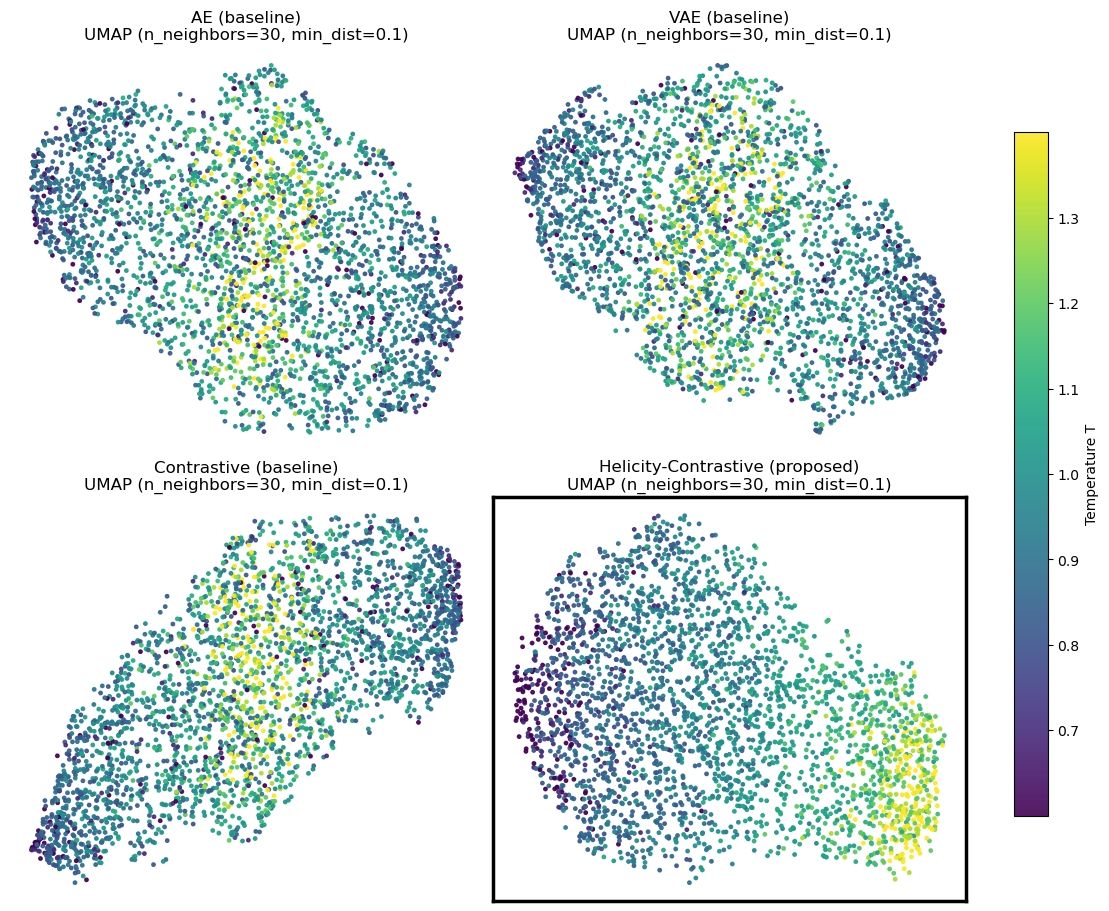

In [10]:
# === UMAP visualization cell (AE / VAE / Contrastive / Helicity-Contrastive) ===
# Assumes you run from: notebooks/ (so ../results/notebook_data exists)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
DATA_DIR = Path("results/notebook_data")

files = {
    "AE (baseline)": DATA_DIR / "ae_latent.npz",
    "VAE (baseline)": DATA_DIR / "vae_latent.npz",  
    "Contrastive (baseline)": DATA_DIR / "contrastive_latent_small.npz",
    "Helicity-Contrastive (proposed)": DATA_DIR / "helicity_contrastive_latent_small.npz",
}

SEED = 42
N_NEIGHBORS = 30
MIN_DIST = 0.10
N_SAMPLES_MAX = 3000  
POINT_SIZE = 6
ALPHA = 0.9

# --- Import UMAP (install message if missing) ---
try:
    import umap
except ImportError as e:
    raise ImportError(
        "UMAP is not installed. Run one of the following in your environment:\n"
        "  pip install umap-learn\n"
        "or (conda)\n"
        "  conda install -c conda-forge umap-learn"
    ) from e


def load_latent(npz_path: Path, n_max: int, seed: int):
    d = np.load(npz_path)
    if "z" not in d or "T" not in d:
        raise KeyError(f"{npz_path.name} must contain 'z' and 'T'. keys={list(d.files)}")

    z = np.asarray(d["z"])
    T = np.asarray(d["T"]).reshape(-1)

    if z.shape[0] != T.shape[0]:
        raise ValueError(f"Length mismatch in {npz_path.name}: z={z.shape}, T={T.shape}")

    # Subsample if needed (deterministic)
    N = z.shape[0]
    if N > n_max:
        rs = np.random.RandomState(seed)
        idx = rs.choice(N, size=n_max, replace=False)
        z = z[idx]
        T = T[idx]

    return z, T


def umap_2d(z, seed, n_neighbors, min_dist):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=seed,
    )
    return reducer.fit_transform(z)


# --- Load all data first (so failures show early) ---
loaded = {}
for name, fp in files.items():
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")
    z, T = load_latent(fp, n_max=N_SAMPLES_MAX, seed=SEED)
    loaded[name] = (z, T)
    print(f"[OK] {name:28s} | z={z.shape} dtype={z.dtype} | T={T.shape} dtype={T.dtype}")

# --- Compute UMAP for each model ---
embeddings = {}
for name, (z, T) in loaded.items():
    print(f"[INFO] UMAP fitting: {name}")
    xy = umap_2d(z, seed=SEED, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST)
    embeddings[name] = (xy, T)

# --- Plot (2x2) ---
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 9),
    constrained_layout=True
)


names = list(files.keys())
vmin = min(np.min(embeddings[n][1]) for n in names)
vmax = max(np.max(embeddings[n][1]) for n in names)

for ax, name in zip(axes.ravel(), names):
    xy, T = embeddings[name]
    sc = ax.scatter(
        xy[:, 0], xy[:, 1],
        c=T,
        s=POINT_SIZE,
        alpha=ALPHA,
        vmin=vmin, vmax=vmax,
    )
    ax.set_title(f"{name}\nUMAP (n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST})")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if "proposed" in name:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)


# --- Shared colorbar (Temperature): put it OUTSIDE the subplots ---
fig.subplots_adjust(right=0.86)  # make room on the right

# [left, bottom, width, height] in figure coordinates (0-1)
cbar = fig.colorbar(
    sc,
    ax=axes,
    location="right",
    shrink=0.8
)
cbar.set_label("Temperature T")

out_path = DATA_DIR / "umap_compare_4models.png"
plt.savefig(out_path, dpi=300)
print(f"[INFO] Saved figure: {out_path}")

plt.show()


### Compute cluster statistics
Cluster statistics are computed using the standalone analysis script.


In [14]:
import subprocess
from pathlib import Path

DATA_DIR = Path("results/notebook_data")
SCRIPT = Path("analysis/cluster_vs_T.py")

latent = DATA_DIR / "helicity_contrastive_latent_small.npz"
out_dir = DATA_DIR  # notebook_dataに出力して管理

cmd = [
    "python", str(SCRIPT),
    "--latent", str(latent),
    "--out_dir", str(out_dir),
    "--n_clusters", "3",
    "--seed", "42",
]

print("Running:\n ", " ".join(cmd))
subprocess.run(cmd, check=True)
print("[OK] cluster_vs_T finished.")


Running:
  python analysis\cluster_vs_T.py --latent results\notebook_data\helicity_contrastive_latent_small.npz --out_dir results\notebook_data --n_clusters 3 --seed 42
[OK] cluster_vs_T finished.


T: (22,) cluster_probs: (22, 3)
[INFO] Saved notebook plot: results\notebook_data\helicity_cluster_prob_vs_T.png


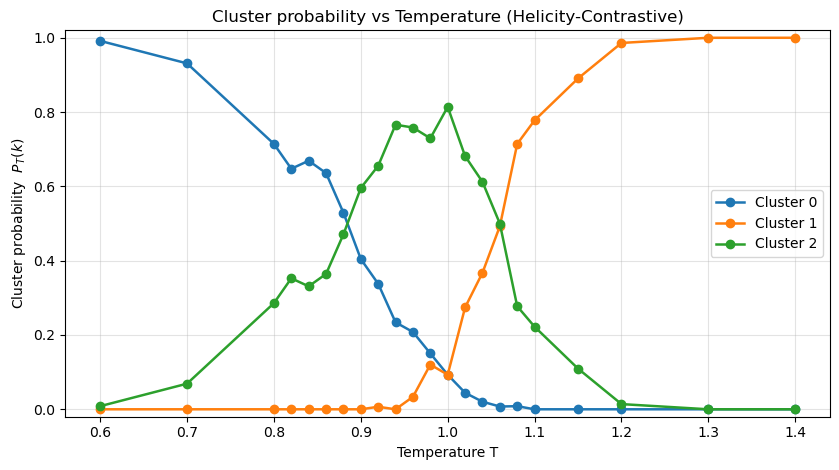

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("results/notebook_data")

stats_path = DATA_DIR / "helicity_contrastive_latent_small_cluster_vs_T.npz"
d = np.load(stats_path)

T = d["T"]
P = d["cluster_probs"]  # (nT, K)

print("T:", T.shape, "cluster_probs:", P.shape)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

K = P.shape[1]
for k in range(K):
    ax.plot(T, P[:, k], marker="o", linewidth=1.8, label=f"Cluster {k}")

ax.set_xlabel("Temperature T")
ax.set_ylabel("Cluster probability  $P_T(k)$")
ax.set_title("Cluster probability vs Temperature (Helicity-Contrastive)")
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.35)
ax.legend(loc="best", frameon=True)

plt.tight_layout()

out_fig = DATA_DIR / "helicity_cluster_prob_vs_T.png"
fig.savefig(out_fig, dpi=300)
print(f"[INFO] Saved notebook plot: {out_fig}")

plt.show()


## Cluster Structure Comparison Across Models

To ensure reproducibility and separation of concerns,  
cluster statistics are computed using the standalone script:

`analysis/cluster_vs_T.py`

For each representation (AE, VAE, Contrastive, Helicity-Contrastive),  
we:

1. Run K-means clustering in latent space
2. Compute temperature-dependent cluster probabilities
3. Compare structural transitions across models

This allows us to evaluate whether the proposed helicity-aware method
captures a clearer three-regime structure.


In [20]:
import sys
import subprocess
from pathlib import Path

DATA_DIR = Path("results/notebook_data")
SCRIPT = Path("analysis/cluster_vs_T.py")

models = {
    "AE": "ae_latent.npz",
    "VAE": "vae_latent.npz",
    "Contrastive": "contrastive_latent_small.npz",
    "Helicity-Contrastive": "helicity_contrastive_latent_small.npz",
}

for name, filename in models.items():
    latent_path = DATA_DIR / filename
    
    cmd = [
        sys.executable,  
        str(SCRIPT),
        "--latent", str(latent_path),
        "--out_dir", str(DATA_DIR),
        "--n_clusters", "3",
        "--seed", "42",
    ]
    
    print(f"\n[Running cluster_vs_T for {name}]")
    subprocess.run(cmd, check=True)

print("\n[OK] All cluster statistics generated.")




[Running cluster_vs_T for AE]

[Running cluster_vs_T for VAE]

[Running cluster_vs_T for Contrastive]

[Running cluster_vs_T for Helicity-Contrastive]

[OK] All cluster statistics generated.


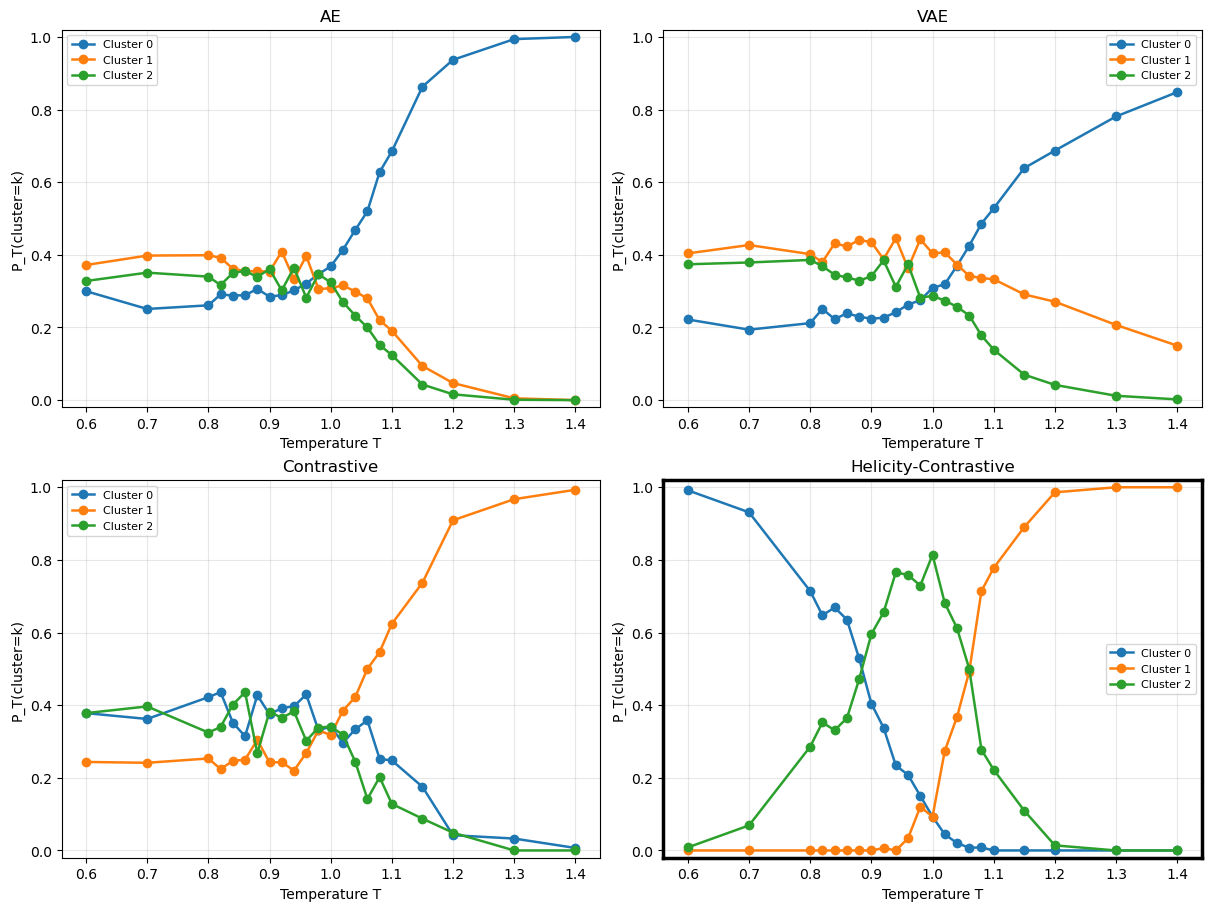

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("results/notebook_data")

models = {
    "AE": "ae_latent_cluster_vs_T.npz",
    "VAE": "vae_latent_cluster_vs_T.npz",
    "Contrastive": "contrastive_latent_small_cluster_vs_T.npz",
    "Helicity-Contrastive": "helicity_contrastive_latent_small_cluster_vs_T.npz",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for ax, (name, filename) in zip(axes, models.items()):
    
    d = np.load(DATA_DIR / filename)
    T = d["T"]
    P = d["cluster_probs"]
    
    K = P.shape[1]
    
    for k in range(K):
        ax.plot(T, P[:, k], marker="o", linewidth=1.8, label=f"Cluster {k}")
    
    ax.set_title(name)
    ax.set_xlabel("Temperature T")
    ax.set_ylabel("P_T(cluster=k)")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    
    if name == "Helicity-Contrastive":
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
    
    ax.legend(fontsize=8)

plt.show()


### Interpretation

Only the helicity-aware model exhibits a clear three-regime structure:

- Low temperature: cluster 0 dominates
- Intermediate regime: cluster 2 emerges distinctly
- High temperature: cluster 1 dominates

This suggests that incorporating helicity information
stabilizes the intermediate structural representation.


## Latent vs Temperature (computed by analysis script)

To keep the notebook lightweight and reproducible, we compute
temperature-dependent latent statistics using the standalone script:

`analysis/latent_vs_T.py`

The notebook runs the script for each model and then loads the saved
figures / statistics for comparison.


[OK] Inputs found. Running latent_vs_T.py ...

[RUN] AE: c:\Users\shona\anaconda3\envs\xy\python.exe analysis\latent_vs_T.py --latent results\notebook_data\ae_latent.npz --out_dir results\notebook_data --max_dims 64
[INFO] T=1.399999976158142: n=1000
[INFO] Saved stats to results\notebook_data\ae_latent_stats_vs_T.npz
[INFO] Saved plot to results\notebook_data\ae_latent_mean_vs_T.png

[RUN] VAE: c:\Users\shona\anaconda3\envs\xy\python.exe analysis\latent_vs_T.py --latent results\notebook_data\vae_latent.npz --out_dir results\notebook_data --max_dims 64
[INFO] T=1.399999976158142: n=1000
[INFO] Saved stats to results\notebook_data\vae_latent_stats_vs_T.npz
[INFO] Saved plot to results\notebook_data\vae_latent_mean_vs_T.png

[RUN] Contrastive: c:\Users\shona\anaconda3\envs\xy\python.exe analysis\latent_vs_T.py --latent results\notebook_data\contrastive_latent_small.npz --out_dir results\notebook_data --max_dims 64
[INFO] T=1.399999976158142: n=145
[INFO] Saved stats to results\notebook_d

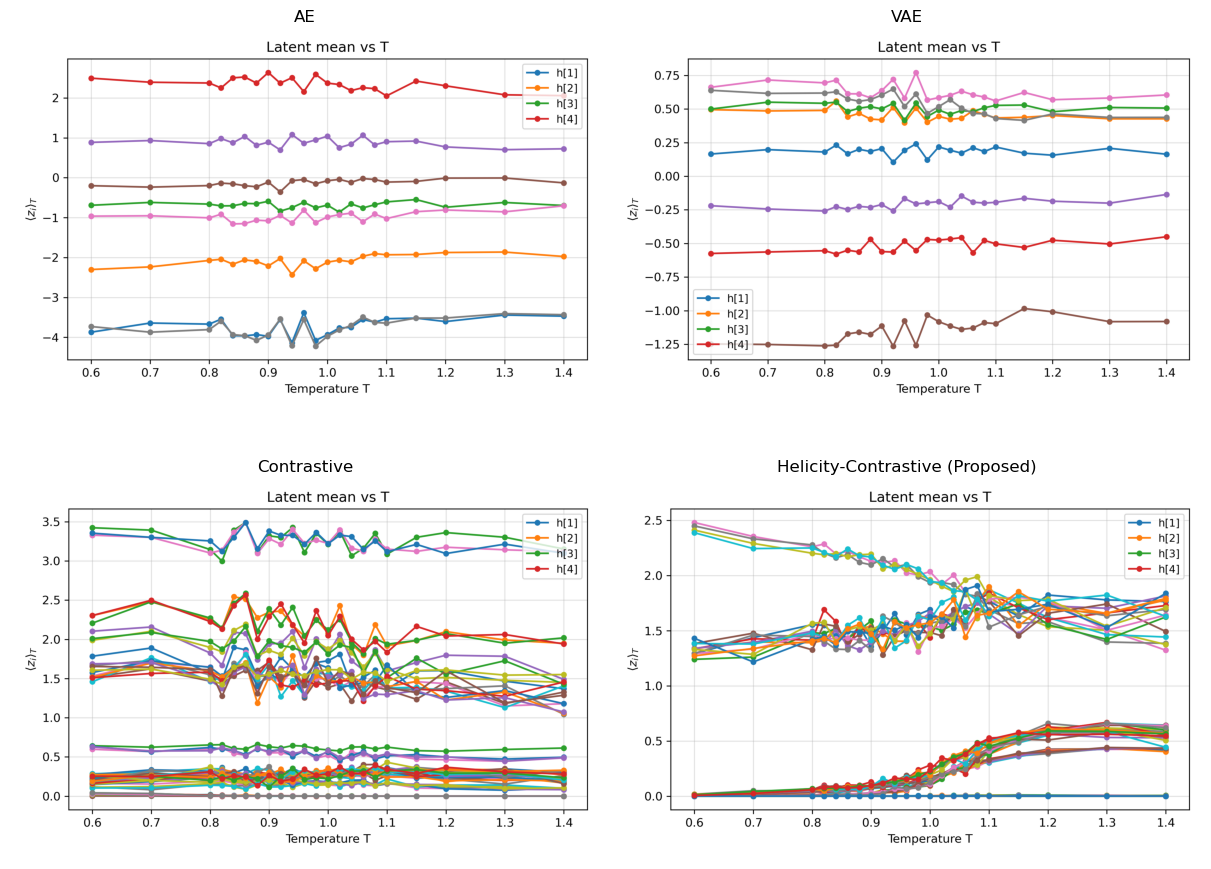

In [34]:
import sys
import subprocess
from pathlib import Path

DATA_DIR = Path("results/notebook_data")
SCRIPT = Path("analysis/latent_vs_T.py")

latents = {
    "AE": DATA_DIR / "ae_latent.npz",
    "VAE": DATA_DIR / "vae_latent.npz",
    "Contrastive": DATA_DIR / "contrastive_latent_small.npz",
    "Helicity-Contrastive (Proposed)": DATA_DIR / "helicity_contrastive_latent_small.npz",
}

OUT_DIR = DATA_DIR
MAX_DIMS = 64

if not SCRIPT.exists():
    raise FileNotFoundError(f"Missing script: {SCRIPT}")

for name, fp in latents.items():
    if not fp.exists():
        raise FileNotFoundError(f"Missing latent for {name}: {fp}")

print("[OK] Inputs found. Running latent_vs_T.py ...")

for name, latent_path in latents.items():
    cmd = [
        sys.executable,
        str(SCRIPT),
        "--latent", str(latent_path),
        "--out_dir", str(OUT_DIR),
        "--max_dims", str(MAX_DIMS),
    ]
    print(f"\n[RUN] {name}: {' '.join(cmd)}")
    res = subprocess.run(cmd, text=True, capture_output=True)

    if res.returncode != 0:
        print("\n[STDOUT]\n", res.stdout)
        print("\n[STDERR]\n", res.stderr)
        raise RuntimeError(f"latent_vs_T.py failed for {name}")

    # 成功ログ（最後だけ）
    if res.stdout:
        print("\n".join(res.stdout.splitlines()[-3:]))

print("\n[OK] Done.")

pngs = {
    "AE": OUT_DIR / "ae_latent_mean_vs_T.png",
    "VAE": OUT_DIR / "vae_latent_mean_vs_T.png",
    "Contrastive": OUT_DIR / "contrastive_latent_small_mean_vs_T.png",
    "Helicity-Contrastive (Proposed)": OUT_DIR / "helicity_contrastive_latent_small_mean_vs_T.png",
}

missing = [str(p) for p in pngs.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Some expected plots were not generated:\n" + "\n".join(missing) +
        "\n\n(If your script uses different filenames, update the 'pngs' dict accordingly.)"
    )

# --- show 2x2 comparison ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for ax, (title, fp) in zip(axes, pngs.items()):
    ax.imshow(Image.open(fp))
    ax.set_title(title)
    ax.axis("off")

plt.show()


## Note on dataset size and correlation analysis

For GitHub compatibility, all notebook demonstrations above were performed
using the reduced latent files (`*_small.npz`, float32, ~3000 samples).

However, correlation analysis is sensitive to sample size.

Therefore:

- The Spearman correlation coefficients shown below
  were computed **locally using the full dataset**
  (not the reduced 3000-sample version).
- Only the resulting CSV ranking files are included in this repository.
- The visualization below loads those precomputed CSV files.

This ensures:
- Reproducibility of the visualization
- Reasonable repository size
- Statistically meaningful correlation estimates


In [35]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("results/notebook_data")

csv_paths = {
    "Y": DATA_DIR / "corr_spearman_Y_top10.csv",
    "nv": DATA_DIR / "corr_spearman_nv_top10.csv",
}

top_dims = {}

for name, fp in csv_paths.items():
    df = pd.read_csv(fp)
    dims = df["dim"].tolist()[:5]   # 上位5個だけ抽出（変更可）
    top_dims[name] = dims
    print(f"\nTop dimensions for {name}:")
    print(dims)



Top dimensions for Y:
[581, 583, 591, 587, 585]

Top dimensions for nv:
[1116, 1112, 1108, 1106, 1105]


## Selected latents vs Temperature (from precomputed correlation CSV)

We use the top-ranked latent dimensions (from locally computed Spearman correlation CSVs)
and visualize their temperature dependence.

To keep the notebook reproducible and modular, the plotting is performed
by the standalone analysis script:

`analysis/plot_selected_latent_vs_T.py`

The notebook only:
1) extracts top dimensions from CSV, and
2) runs the script to generate figures.


[INFO] Top dims (Y):  [581, 583, 591, 587, 585]
[INFO] Top dims (nv): [1116, 1112, 1108, 1106, 1105]

[RUN] c:\Users\shona\anaconda3\envs\xy\python.exe analysis\plot_selected_latent_vs_T.py --latent results\notebook_data\helicity_contrastive_latent_small.npz --dims 581,583,591,587,585 --out_dir results\notebook_data --label_prefix z --title Top-5 latents (Spearman vs Y): mean vs T --ylabel $\langle z_i \rangle_T$ --with_std
[OK] Saved (overwrite): results\notebook_data\Y_helicity_contrastive_latent_small_selected_mean_vs_T.png

[RUN] c:\Users\shona\anaconda3\envs\xy\python.exe analysis\plot_selected_latent_vs_T.py --latent results\notebook_data\helicity_contrastive_latent_small.npz --dims 1116,1112,1108,1106,1105 --out_dir results\notebook_data --label_prefix z --title Top-5 latents (Spearman vs nv): mean vs T --ylabel $\langle z_i \rangle_T$ --with_std
[OK] Saved (overwrite): results\notebook_data\nv_helicity_contrastive_latent_small_selected_mean_vs_T.png


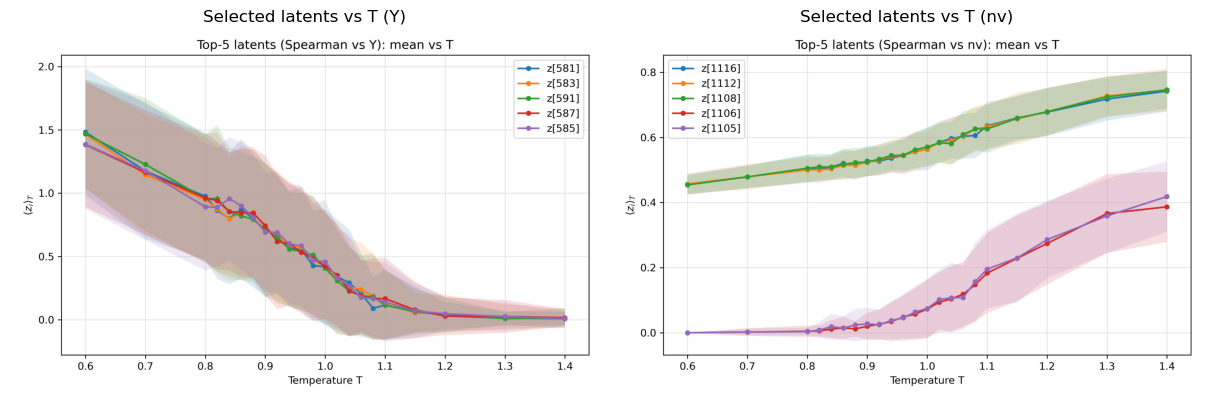

In [46]:
import sys
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("results/notebook_data")

# analysis script (uploaded)
SCRIPT = Path("analysis/plot_selected_latent_vs_T.py")

# latent to plot (proposed)
LATENT = DATA_DIR / "helicity_contrastive_latent_small.npz"

# precomputed CSVs (local full-data results)
CSV_Y  = DATA_DIR / "corr_spearman_Y_top10.csv"
CSV_NV = DATA_DIR / "corr_spearman_nv_top10.csv"

OUT_DIR = DATA_DIR
TOPK = 5
WITH_STD = True  # ±1σ shading

# --- checks ---
for fp in [SCRIPT, LATENT, CSV_Y, CSV_NV]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing: {fp}")

def top_dims_from_csv(csv_path: Path, k: int):
    df = pd.read_csv(csv_path)
    if "dim" not in df.columns:
        raise ValueError(f"'dim' column not found in {csv_path.name}. columns={list(df.columns)}")
    return df["dim"].tolist()[:k]

dims_Y  = top_dims_from_csv(CSV_Y, TOPK)
dims_nv = top_dims_from_csv(CSV_NV, TOPK)

print("[INFO] Top dims (Y): ", dims_Y)
print("[INFO] Top dims (nv):", dims_nv)

import os

def safe_replace(src: Path, dst: Path):
    """
    Windows-friendly overwrite:
    - remove dst if exists
    - then rename src -> dst
    """
    if dst.exists():
        dst.unlink()
    src.rename(dst)

def run_plot(dims, title, out_prefix):
    dims_str = ",".join(str(int(x)) for x in dims)

    cmd = [
        sys.executable,
        str(SCRIPT),
        "--latent", str(LATENT),
        "--dims", dims_str,
        "--out_dir", str(OUT_DIR),
        "--label_prefix", "z",
        "--title", title,
        "--ylabel", r"$\langle z_i \rangle_T$",
    ]
    if WITH_STD:
        cmd.append("--with_std")

    print("\n[RUN]", " ".join(cmd))
    res = subprocess.run(cmd, text=True, capture_output=True)

    if res.returncode != 0:
        print("\n[STDOUT]\n", res.stdout)
        print("\n[STDERR]\n", res.stderr)
        raise RuntimeError("plot_selected_latent_vs_T.py failed")

    generated_png = OUT_DIR / f"{LATENT.stem}_selected_mean_vs_T.png"
    generated_npz = OUT_DIR / f"{LATENT.stem}_selected_stats_vs_T.npz"

    if not generated_png.exists():
        raise FileNotFoundError(f"Expected output not found: {generated_png}")

    new_png = OUT_DIR / f"{out_prefix}_{LATENT.stem}_selected_mean_vs_T.png"
    new_npz = OUT_DIR / f"{out_prefix}_{LATENT.stem}_selected_stats_vs_T.npz"

    # overwrite-safe rename
    safe_replace(generated_png, new_png)
    if generated_npz.exists():
        safe_replace(generated_npz, new_npz)

    print(f"[OK] Saved (overwrite): {new_png}")
    return new_png


png_Y  = run_plot(dims_Y,  f"Top-{TOPK} latents (Spearman vs Y): mean vs T",  "Y")
png_nv = run_plot(dims_nv, f"Top-{TOPK} latents (Spearman vs nv): mean vs T", "nv")

# --- show side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].imshow(Image.open(png_Y));  axes[0].set_title("Selected latents vs T (Y)");  axes[0].axis("off")
axes[1].imshow(Image.open(png_nv)); axes[1].set_title("Selected latents vs T (nv)"); axes[1].axis("off")
plt.show()


## Interpretation

The results reveal a clear qualitative difference between baseline models
and the proposed helicity-aware representation.

### 1. Latent structure across models

- **AE / VAE**
  - Latent means vary weakly or irregularly with temperature.
  - No clear monotonic structure across the transition.
  - The representation does not cleanly encode phase information.

- **Contrastive (baseline)**
  - Some latent dimensions show structured variation with temperature.
  - However, the transition behavior remains mixed and not sharply separated.

- **Helicity-Contrastive (Proposed)**
  - Several latent dimensions exhibit smooth and monotonic variation with temperature.
  - Distinct low-temperature, intermediate, and high-temperature regimes emerge.
  - The representation shows structured reorganization near the transition region.

---

### 2. Correlation with physical observables

Using full-dataset Spearman correlation (computed locally):

- Certain latent dimensions strongly correlate with:
  - **Y (helicity-related quantity)**
  - **nv (vortex density)**

Selected top-ranked dimensions display:

- Clear temperature-dependent trends
- Distinct inflection near the transition region
- Reduced variance within phases

This suggests that:

> The proposed model organizes latent space along physically meaningful axes.

---

### 3. Phase transition encoding

In the helicity-aware model:

- Low temperature:
  - Latent dimensions associated with order dominate.
- Intermediate regime:
  - Transition-like smooth crossover appears.
- High temperature:
  - Different latent coordinates become dominant.

This behavior is consistent with:

- Emergence of vortex excitations
- Reorganization of helicity-related structure
- Phase-dependent feature disentanglement

---

### 4. Key insight

The improvement is not merely clustering.

The proposed model appears to:

- Align latent coordinates with physically relevant observables
- Encode phase structure in a geometrically smooth manner
- Separate regimes more cleanly than baselines

This indicates that incorporating helicity information stabilizes
physically interpretable representation learning.


# Appendix

## Quantifying transition sensitivity: slope of latent means

Visual inspection suggests that the proposed representation reorganizes near the transition region.
To quantify this, we compute the temperature-derivative of latent means:

\[
\frac{d\langle z_i \rangle_T}{dT}
\]

A large absolute slope indicates a latent coordinate that is highly sensitive to temperature changes,
often peaking around structural reorganization (transition-like) regimes.

Below, we compute slopes for the top-ranked latent dimensions
(from the precomputed Spearman correlation CSVs) and report:

- slope curves vs temperature
- the temperature at which each latent dimension attains its maximum |slope|


[INFO] Top dims (Y):  [581, 583, 591, 587, 585]
[INFO] Top dims (nv): [1116, 1112, 1108, 1106, 1105]


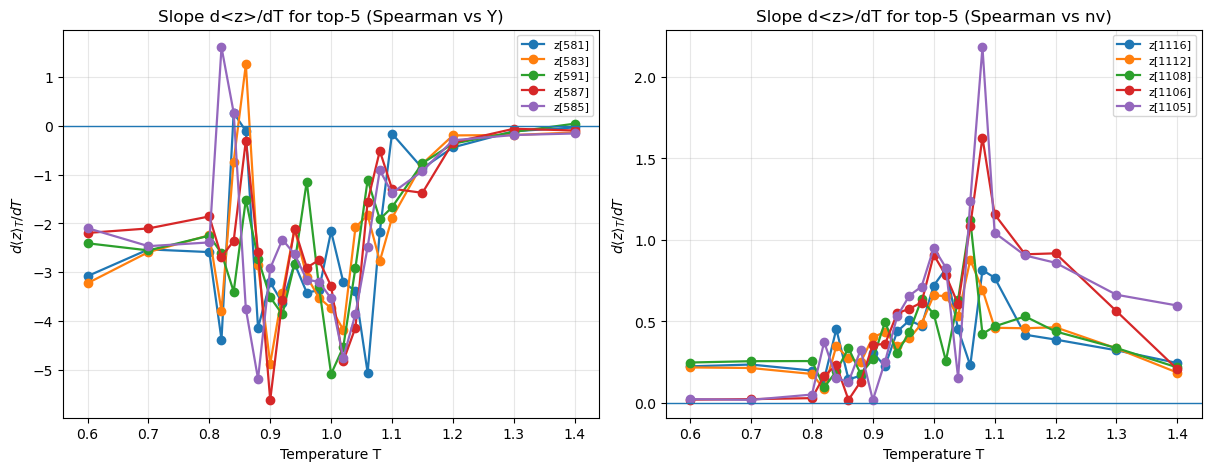


[PEAKS] Top dims (Y) : max |d<z>/dT|
dim | T_peak | slope_at_peak | |slope|
 581 |  1.060 | -5.0588 |  5.0588
 583 |  0.900 | -4.8777 |  4.8777
 591 |  1.000 | -5.0860 |  5.0860
 587 |  0.900 | -5.6204 |  5.6204
 585 |  0.880 | -5.1863 |  5.1863

[PEAKS] Top dims (nv): max |d<z>/dT|
dim | T_peak | slope_at_peak | |slope|
1116 |  1.020 |  0.8229 |  0.8229
1112 |  1.060 |  0.8778 |  0.8778
1108 |  1.060 |  1.1201 |  1.1201
1106 |  1.080 |  1.6271 |  1.6271
1105 |  1.080 |  2.1810 |  2.1810


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# Config
# -----------------------
DATA_DIR = Path("results/notebook_data")

LATENT_FP = DATA_DIR / "helicity_contrastive_latent_small.npz"  # proposed (small for GitHub)
CSV_Y  = DATA_DIR / "corr_spearman_Y_top10.csv"   # computed locally on full data
CSV_NV = DATA_DIR / "corr_spearman_nv_top10.csv"  # computed locally on full data

TOPK = 5  # number of selected dims to analyze
USE_ABS_SORT = True  # if CSV has abs_corr, you may want to sort by it

# -----------------------
# Helpers
# -----------------------
def load_dims(csv_path: Path, k: int):
    df = pd.read_csv(csv_path)
    if "dim" not in df.columns:
        raise ValueError(f"'dim' column not found in {csv_path.name}. columns={list(df.columns)}")

    # If your CSV includes abs_corr, prefer it (more robust for sign flips)
    if USE_ABS_SORT and "abs_corr" in df.columns:
        df = df.sort_values("abs_corr", ascending=False)
    elif "corr" in df.columns:
        df = df.sort_values("corr", ascending=False)

    dims = df["dim"].head(k).tolist()
    return [int(x) for x in dims]

def mean_by_T(z: np.ndarray, T: np.ndarray):
    Tuniq = np.sort(np.unique(T))
    mu = np.zeros((Tuniq.size, z.shape[1]), dtype=np.float64)
    for i, t in enumerate(Tuniq):
        m = (T == t)
        mu[i] = z[m].mean(axis=0)
    return Tuniq, mu

def central_diff(T: np.ndarray, y: np.ndarray):
    """
    Central difference slope for non-uniform T.
    y: (nT,)
    returns slope (nT,) with forward/backward at ends.
    """
    dy = np.zeros_like(y, dtype=np.float64)
    n = len(T)
    if n < 10:
        # fallback
        dy[1:] = (y[1:] - y[:-1]) / (T[1:] - T[:-1])
        dy[0] = dy[1] if n > 1 else 0.0
        return dy

    # endpoints: forward/backward
    dy[0]  = (y[1] - y[0]) / (T[1] - T[0])
    dy[-1] = (y[-1] - y[-2]) / (T[-1] - T[-2])

    # interior: central
    for i in range(1, n - 1):
        dy[i] = (y[i + 1] - y[i - 1]) / (T[i + 1] - T[i - 1])
    return dy

# -----------------------
# Load
# -----------------------
for fp in [LATENT_FP, CSV_Y, CSV_NV]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing: {fp}")

d = np.load(LATENT_FP)
if "z" not in d or "T" not in d:
    raise KeyError("latent npz must contain 'z' and 'T'.")

z = np.asarray(d["z"])
T = np.asarray(d["T"]).ravel()

dims_Y  = load_dims(CSV_Y, TOPK)
dims_nv = load_dims(CSV_NV, TOPK)

print("[INFO] Top dims (Y): ", dims_Y)
print("[INFO] Top dims (nv):", dims_nv)

Tuniq, mu = mean_by_T(z, T)

# -----------------------
# Compute slopes for selected dims
# -----------------------
def compute_slopes(dims):
    slopes = {}
    peaks = {}
    for dim in dims:
        y = mu[:, dim]
        s = central_diff(Tuniq, y)
        slopes[dim] = s
        i_peak = int(np.argmax(np.abs(s)))
        peaks[dim] = (Tuniq[i_peak], s[i_peak], float(np.abs(s[i_peak])))
    return slopes, peaks

slopes_Y, peaks_Y   = compute_slopes(dims_Y)
slopes_nv, peaks_nv = compute_slopes(dims_nv)

# -----------------------
# Plot (side-by-side)
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

# Left: Y
ax = axes[0]
for dim in dims_Y:
    ax.plot(Tuniq, slopes_Y[dim], marker="o", linewidth=1.6, label=f"z[{dim}]")
ax.axhline(0.0, linewidth=1.0)
ax.set_title(f"Slope d<z>/dT for top-{TOPK} (Spearman vs Y)")
ax.set_xlabel("Temperature T")
ax.set_ylabel(r"$d\langle z\rangle_T / dT$")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, frameon=True)

# Right: nv
ax = axes[1]
for dim in dims_nv:
    ax.plot(Tuniq, slopes_nv[dim], marker="o", linewidth=1.6, label=f"z[{dim}]")
ax.axhline(0.0, linewidth=1.0)
ax.set_title(f"Slope d<z>/dT for top-{TOPK} (Spearman vs nv)")
ax.set_xlabel("Temperature T")
ax.set_ylabel(r"$d\langle z\rangle_T / dT$")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, frameon=True)

plt.show()

# -----------------------
# Report peak temperatures
# -----------------------
def print_peaks(title, peaks_dict):
    print("\n" + title)
    print("dim | T_peak | slope_at_peak | |slope|")
    for dim, (t_peak, slope_peak, abs_slope) in peaks_dict.items():
        print(f"{dim:4d} | {t_peak:6.3f} | {slope_peak: .4f} | {abs_slope: .4f}")

print_peaks("[PEAKS] Top dims (Y) : max |d<z>/dT|", peaks_Y)
print_peaks("[PEAKS] Top dims (nv): max |d<z>/dT|", peaks_nv)


## Overlay: slope-peak temperatures on selected latents vs T

To highlight where the representation changes most sharply, we compute the temperature
at which each selected latent dimension attains its maximum absolute slope:

\[
T_{\mathrm{peak}} = \arg\max_T \left| \frac{d\langle z_i\rangle_T}{dT} \right|
\]

We then overlay vertical lines at these peak temperatures on the
"selected latents vs T" plots.


[INFO] peak Ts (Y): {581: 1.059999942779541, 583: 0.8999999761581421, 591: 1.0, 587: 0.8999999761581421, 585: 0.8799999952316284}
[INFO] peak Ts (nv): {1116: 1.0199999809265137, 1112: 1.059999942779541, 1108: 1.059999942779541, 1106: 1.0800000429153442, 1105: 1.0800000429153442}


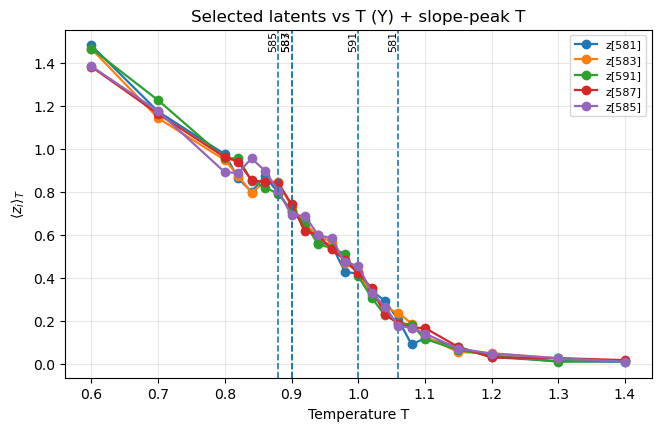

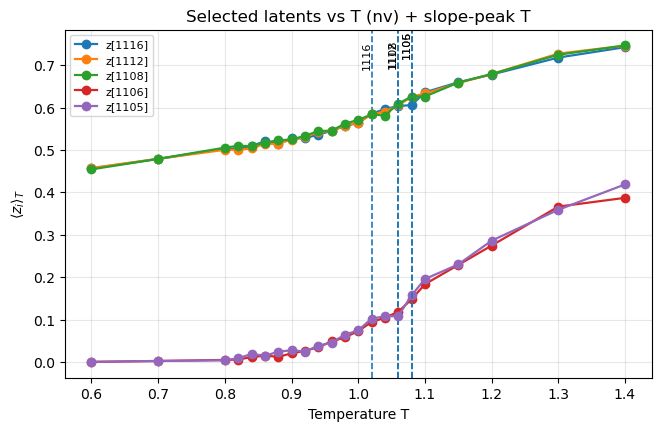

[OK] Saved:
 - results\notebook_data\Y_helicity_contrastive_latent_small_selected_mean_vs_T_with_peaks.png
 - results\notebook_data\nv_helicity_contrastive_latent_small_selected_mean_vs_T_with_peaks.png


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("results/notebook_data")
LATENT_FP = DATA_DIR / "helicity_contrastive_latent_small.npz"

CSV_Y  = DATA_DIR / "corr_spearman_Y_top10.csv"
CSV_NV = DATA_DIR / "corr_spearman_nv_top10.csv"

TOPK = 5
USE_ABS_SORT = True

# base plots created by plot_selected_latent_vs_T.py (your renamed outputs)
BASE_Y  = DATA_DIR / "Y_helicity_contrastive_latent_small_selected_mean_vs_T.png"
BASE_NV = DATA_DIR / "nv_helicity_contrastive_latent_small_selected_mean_vs_T.png"

OUT_Y  = DATA_DIR / "Y_helicity_contrastive_latent_small_selected_mean_vs_T_with_peaks.png"
OUT_NV = DATA_DIR / "nv_helicity_contrastive_latent_small_selected_mean_vs_T_with_peaks.png"

for fp in [LATENT_FP, CSV_Y, CSV_NV, BASE_Y, BASE_NV]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing: {fp}")

def load_dims(csv_path: Path, k: int):
    df = pd.read_csv(csv_path)
    if "dim" not in df.columns:
        raise ValueError(f"'dim' column not found in {csv_path.name}: {list(df.columns)}")
    if USE_ABS_SORT and "abs_corr" in df.columns:
        df = df.sort_values("abs_corr", ascending=False)
    elif "corr" in df.columns:
        df = df.sort_values("corr", ascending=False)
    return [int(x) for x in df["dim"].head(k).tolist()]

def mean_by_T(z: np.ndarray, T: np.ndarray):
    Tuniq = np.sort(np.unique(T))
    mu = np.zeros((Tuniq.size, z.shape[1]), dtype=np.float64)
    for i, t in enumerate(Tuniq):
        m = (T == t)
        mu[i] = z[m].mean(axis=0)
    return Tuniq, mu

def central_diff(T: np.ndarray, y: np.ndarray):
    dy = np.zeros_like(y, dtype=np.float64)
    n = len(T)
    dy[0]  = (y[1] - y[0]) / (T[1] - T[0])
    dy[-1] = (y[-1] - y[-2]) / (T[-1] - T[-2])
    for i in range(1, n - 1):
        dy[i] = (y[i + 1] - y[i - 1]) / (T[i + 1] - T[i - 1])
    return dy

def peak_Ts_for_dims(Tuniq, mu, dims):
    peaks = {}
    for dim in dims:
        s = central_diff(Tuniq, mu[:, dim])
        i_peak = int(np.argmax(np.abs(s)))
        peaks[dim] = float(Tuniq[i_peak])
    return peaks

# ---- load latent and compute T-mean ----
d = np.load(LATENT_FP)
z = np.asarray(d["z"])
T = np.asarray(d["T"]).ravel()
Tuniq, mu = mean_by_T(z, T)

dims_Y  = load_dims(CSV_Y, TOPK)
dims_nv = load_dims(CSV_NV, TOPK)

peaks_Y  = peak_Ts_for_dims(Tuniq, mu, dims_Y)
peaks_nv = peak_Ts_for_dims(Tuniq, mu, dims_nv)

print("[INFO] peak Ts (Y):", peaks_Y)
print("[INFO] peak Ts (nv):", peaks_nv)

# ---- re-plot from data (best quality overlay) ----
def plot_with_peaks(dims, title, out_path, peak_map):
    fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)

    for dim in dims:
        y = mu[:, dim]
        ax.plot(Tuniq, y, marker="o", linewidth=1.6, label=f"z[{dim}]")

        # vertical line at peak
        tpk = peak_map[dim]
        ax.axvline(tpk, linestyle="--", linewidth=1.2)
        # small text label (avoid clutter: only show dim)
        ax.text(tpk, ax.get_ylim()[1], f"{dim}", rotation=90, va="top", ha="right", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("Temperature T")
    ax.set_ylabel(r"$\langle z_i \rangle_T$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, frameon=True)

    plt.savefig(out_path, dpi=200)
    plt.show()

plot_with_peaks(
    dims_Y,
    f"Selected latents vs T (Y) + slope-peak T",
    OUT_Y,
    peaks_Y
)

plot_with_peaks(
    dims_nv,
    f"Selected latents vs T (nv) + slope-peak T",
    OUT_NV,
    peaks_nv
)

print("[OK] Saved:")
print(" -", OUT_Y)
print(" -", OUT_NV)


### Comparison with estimated transition temperature

Monte Carlo simulation and theoretical considerations suggest
a transition temperature of approximately:

T_c ≈ 0.917

From slope analysis:

- Y-related latent dimensions peak around T ≈ 0.88–0.90
- nv-related latent dimensions peak around T ≈ 1.02–1.08

This asymmetry is physically meaningful:

- Helicity-related quantities (Y) become unstable slightly below T_c,
  reflecting pre-transition fluctuations.
- Vortex density (nv) increases more strongly above T_c,
  reflecting post-transition disorder.

Thus, the learned representation appears to capture
transition-sensitive structure from both sides of the critical region.

The representation does not merely cluster phases,
but encodes physically interpretable transition dynamics.


# 🔬 Cluster-conditioned Correlation Function Analysis

## 1️⃣ Purpose

To verify whether the cluster separation obtained via **UMAP + K-means**
reflects *actual physical ordering* in the 2D XY model.

Specifically, for each cluster:

- We compute the spin correlation function

\[
G(r) = \langle \cos(\theta_i - \theta_{i+r}) \rangle
\]

- We compare its decay behavior across temperatures.

This allows us to determine whether clusters correspond to:

- Quasi-long-range order (power-law decay)
- Critical/intermediate behavior
- Disordered phase (exponential decay)

---

## 2️⃣ Execution Script

The correlation analysis is performed locally using:

analysis/cluster_cond_G_r.py


### Input

- `*_cluster_vs_T.npz` (cluster labels)
- Monte Carlo spin configurations

### Output

- Cluster-conditioned averaged correlation function
- log–log and semi-log plots
- Saved PNG files

> ⚠️ Note  
> Due to GitHub size limitations, the notebook uses small latent data.  
> Correlation function analysis is performed locally on full MC data,  
> and the resulting PNG figures are displayed below.


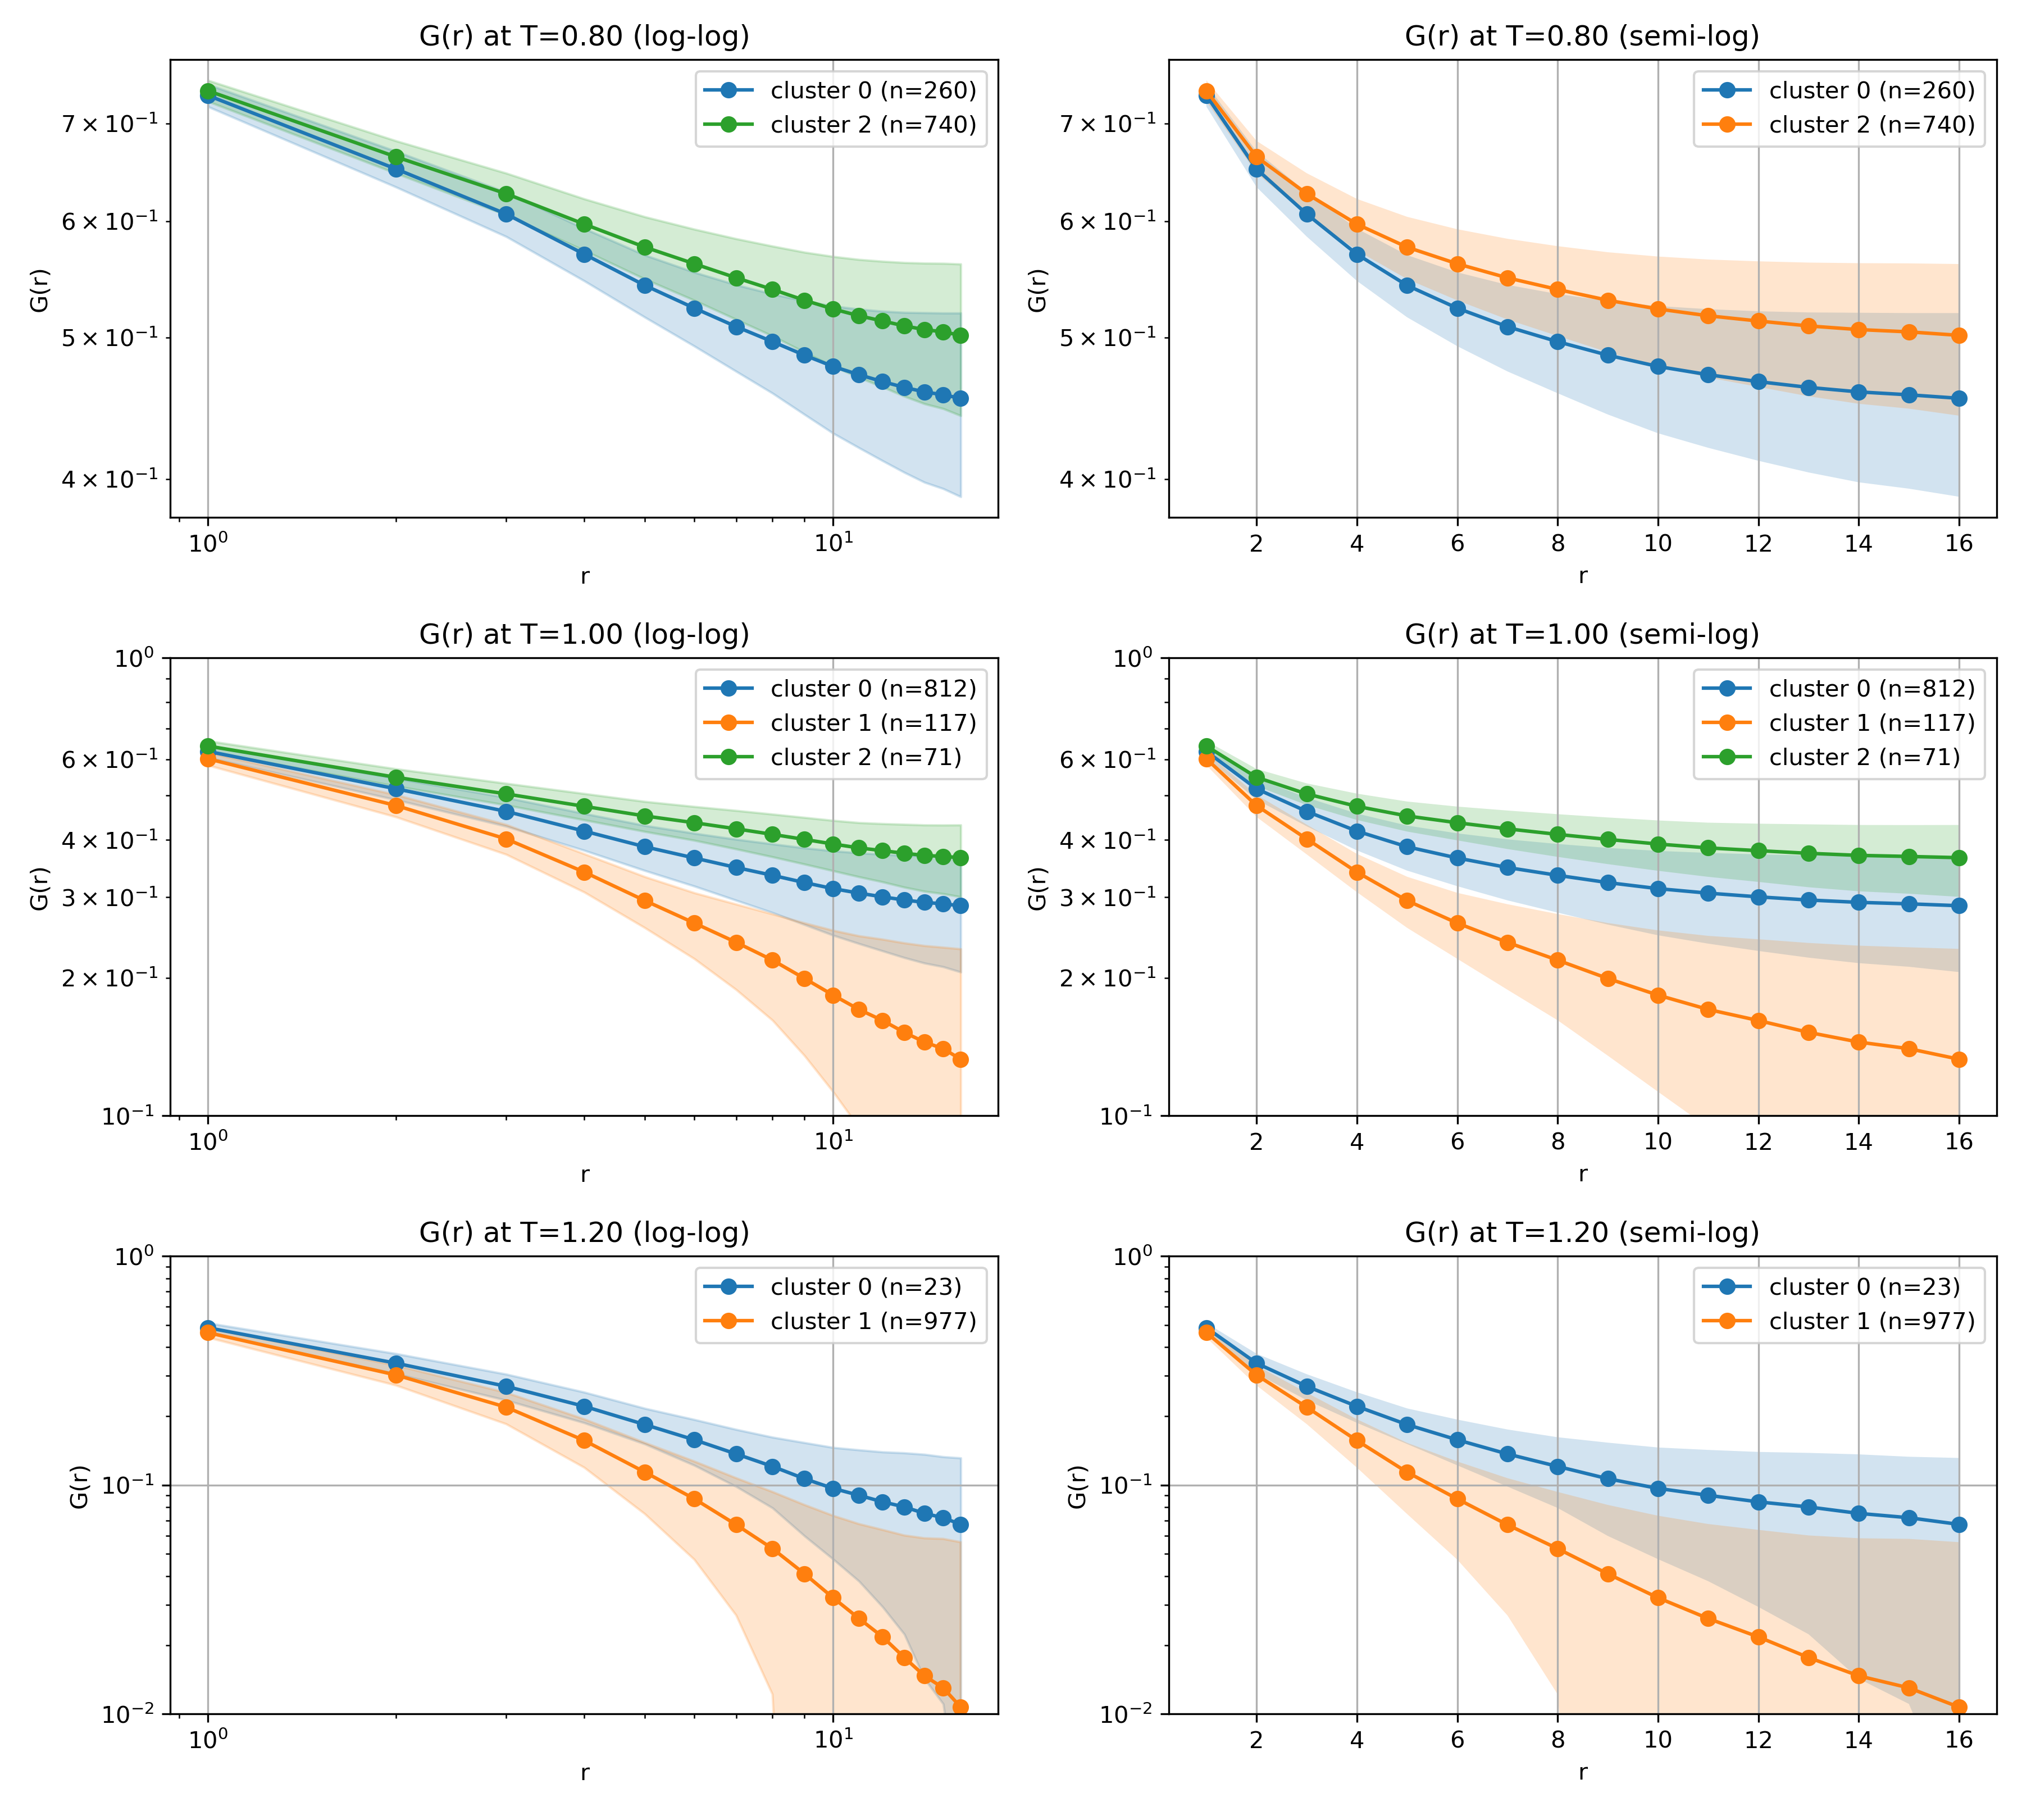

In [48]:
from pathlib import Path
from IPython.display import Image, display

IMG_PATH = Path("results/notebook_data/cluster_cond_G_r_T080_T100_T120.png")

if not IMG_PATH.exists():
    raise FileNotFoundError(f"Missing image: {IMG_PATH}")

display(Image(filename=str(IMG_PATH)))


# 🧠 Interpretation

## 🔹 T = 0.80 (Low-temperature phase)

- Nearly linear behavior in log–log scale
- Curved in semi-log scale

→ Indicates **power-law decay**  
→ Characteristic of the KT quasi-long-range ordered phase

Clusters 0 and 2 both belong to the low-temperature regime,  
but exhibit slightly different decay exponents.

---

## 🔹 T = 1.00 (Near transition)

- One cluster exhibits much faster decay
- Others remain relatively slow-decaying

→ Suggests the presence of an **intermediate structure**
→ Consistent with the "middle layer" observed in UMAP

This supports the idea that latent clusters capture transitional physics.

---

## 🔹 T = 1.20 (High-temperature phase)

- Linear behavior in semi-log scale
- Curved in log–log scale

→ Indicates **exponential decay**
→ Disordered phase with short correlation length

High-temperature clusters clearly exhibit short-range correlations only.

---

# 📌 Conclusion

The latent-space clustering does not merely separate geometrically.

It corresponds directly to physically distinct regimes:

- Quasi-long-range ordered phase
- Near-critical region
- Disordered phase

This demonstrates that the learned representation encodes
physically meaningful structure beyond simple temperature labels.
